In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

In [ ]:
df=pd.read_csv("../preprocessing/daily_sales.csv")

In [ ]:
df.head()

,Order Date,Total amount
0,2011-01-01,808.56300
1,2011-01-02,314.22000
2,2011-01-03,4503.53720
3,2011-01-04,2808.87024
4,2011-01-05,3662.31000


In [ ]:
print(df.shape)
df.info()
df.describe()

(1430, 2)
<class 'pandas.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    1430 non-null   str    
 1   Total amount  1430 non-null   float64
dtypes: float64(1), str(1)
memory usage: 36.4 KB


,Total amount
count,1430.000000
mean,8840.910426
std,6570.117413
min,2.688000
25%,3794.655250
50%,7700.144280
75%,12466.365500
max,39536.132000


In [ ]:
df = df.rename(columns={
    "Order Date": "ds",
    "Total amount": "y"
})

In [ ]:
df["ds"] = pd.to_datetime(df["ds"])

In [ ]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

def find_best_seasonality(df):
    print("Testing Additive Model...")
    model_add = Prophet(seasonality_mode='additive')
    model_add.fit(df)
    # Adjust initial, period, and horizon based on how much data you have
    cv_add = cross_validation(model_add, initial='730 days', period='180 days', horizon='30 days')
    metrics_add = performance_metrics(cv_add)
    rmse_add = metrics_add['rmse'].mean() #type:ignore
    
    print("Testing Multiplicative Model...")
    model_mult = Prophet(seasonality_mode='multiplicative')
    model_mult.fit(df)
    cv_mult = cross_validation(model_mult, initial='730 days', period='180 days', horizon='30 days')
    metrics_mult = performance_metrics(cv_mult)
    rmse_mult = metrics_mult['rmse'].mean() #type:ignore
    
    print("-" * 30)
    # RMSE represents the average error in your actual units (INR)
    print(f"Additive Error (RMSE): ₹{rmse_add:,.2f}")
    print(f"Multiplicative Error (RMSE): ₹{rmse_mult:,.2f}")
    print("-" * 30)
    
    if rmse_mult < rmse_add:
        print("Winner: MULTIPLICATIVE (The seasonal swings grow with your sales)")
    else:
        print("Winner: ADDITIVE (The seasonal swings stay relatively constant)")

# Run the function (Replace 'df' with whatever your cleaned dataframe is named)
find_best_seasonality(df)

13:12:36 - cmdstanpy - INFO - Chain [1] start processing


Testing Additive Model...


13:12:36 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/4 [00:00<?, ?it/s]13:12:36 - cmdstanpy - INFO - Chain [1] start processing
13:12:36 - cmdstanpy - INFO - Chain [1] done processing
 25%|██▌       | 1/4 [00:00<00:00,  5.49it/s]13:12:36 - cmdstanpy - INFO - Chain [1] start processing
13:12:36 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:00<00:00,  4.96it/s]13:12:36 - cmdstanpy - INFO - Chain [1] start processing
13:12:36 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 3/4 [00:00<00:00,  4.98it/s]13:12:37 - cmdstanpy - INFO - Chain [1] start processing
13:12:37 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 4/4 [00:00<00:00,  4.77it/s]
13:12:37 - cmdstanpy - INFO - Chain [1] start processing
13:12:37 - cmdstanpy - INFO - Chain [1] done processing


Testing Multiplicative Model...


  0%|          | 0/4 [00:00<?, ?it/s]13:12:37 - cmdstanpy - INFO - Chain [1] start processing
13:12:37 - cmdstanpy - INFO - Chain [1] done processing
 25%|██▌       | 1/4 [00:00<00:00,  5.53it/s]13:12:37 - cmdstanpy - INFO - Chain [1] start processing
13:12:37 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:00<00:00,  5.23it/s]13:12:37 - cmdstanpy - INFO - Chain [1] start processing
13:12:38 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 3/4 [00:00<00:00,  5.11it/s]13:12:38 - cmdstanpy - INFO - Chain [1] start processing
13:12:38 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 4/4 [00:00<00:00,  4.91it/s]

------------------------------
Additive Error (RMSE): ₹5,868.93
Multiplicative Error (RMSE): ₹5,532.20
------------------------------
Winner: MULTIPLICATIVE (The seasonal swings grow with your sales)


In [ ]:
model=Prophet(seasonality_mode='multiplicative')

In [ ]:
model.fit(df)

13:12:38 - cmdstanpy - INFO - Chain [1] start processing
13:12:38 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future=model.make_future_dataframe(periods=30)

In [ ]:
forecast=model.predict(future)

In [ ]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2011-01-01,4782.858266,-1600.564293,8748.698422,4782.858266,4782.858266,-0.279066,-0.279066,-0.279066,-0.362065,-0.362065,-0.362065,0.082999,0.082999,0.082999,0.0,0.0,0.0,3448.126393
1,2011-01-02,4788.450514,-4365.205347,5934.988795,4788.450514,4788.450514,-0.861223,-0.861223,-0.861223,-0.904616,-0.904616,-0.904616,0.043393,0.043393,0.043393,0.0,0.0,0.0,664.526183
2,2011-01-03,4794.042763,1109.688532,10970.548694,4794.042763,4794.042763,0.245920,0.245920,0.245920,0.242848,0.242848,0.242848,0.003072,0.003072,0.003072,0.0,0.0,0.0,5972.994599
3,2011-01-04,4799.635011,712.278098,11126.184984,4799.635011,4799.635011,0.224053,0.224053,0.224053,0.261476,0.261476,0.261476,-0.037422,-0.037422,-0.037422,0.0,0.0,0.0,5875.008489
4,2011-01-05,4805.227260,-217.812281,10592.287032,4805.227260,4805.227260,0.132277,0.132277,0.132277,0.209819,0.209819,0.209819,-0.077542,-0.077542,-0.077542,0.0,0.0,0.0,5440.849031


In [ ]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30)

,ds,yhat,yhat_lower,yhat_upper
1430,2015-01-01,17590.450250,12661.928408,23265.539812
1431,2015-01-02,17657.033081,12766.513401,22657.041787
1432,2015-01-03,8442.283419,3248.709918,14105.567660
1433,2015-01-04,763.877763,-4144.524324,6231.558044
1434,2015-01-05,15367.810276,10199.451820,20641.420377
1435,2015-01-06,15106.435618,9892.662188,20734.086537
1436,2015-01-07,13935.593317,8593.844674,18986.161815
1437,2015-01-08,14060.123191,8451.191411,19341.883157
1438,2015-01-09,14205.996424,8735.532636,19497.829095
1439,2015-01-10,5073.941076,-550.067172,9968.225217


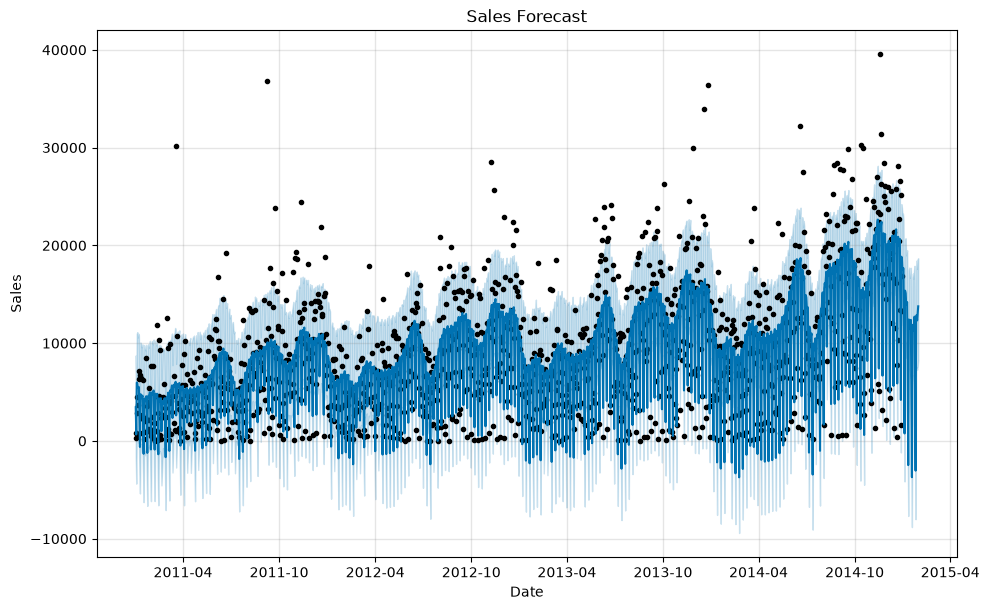

In [ ]:
fig = model.plot(forecast)

plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

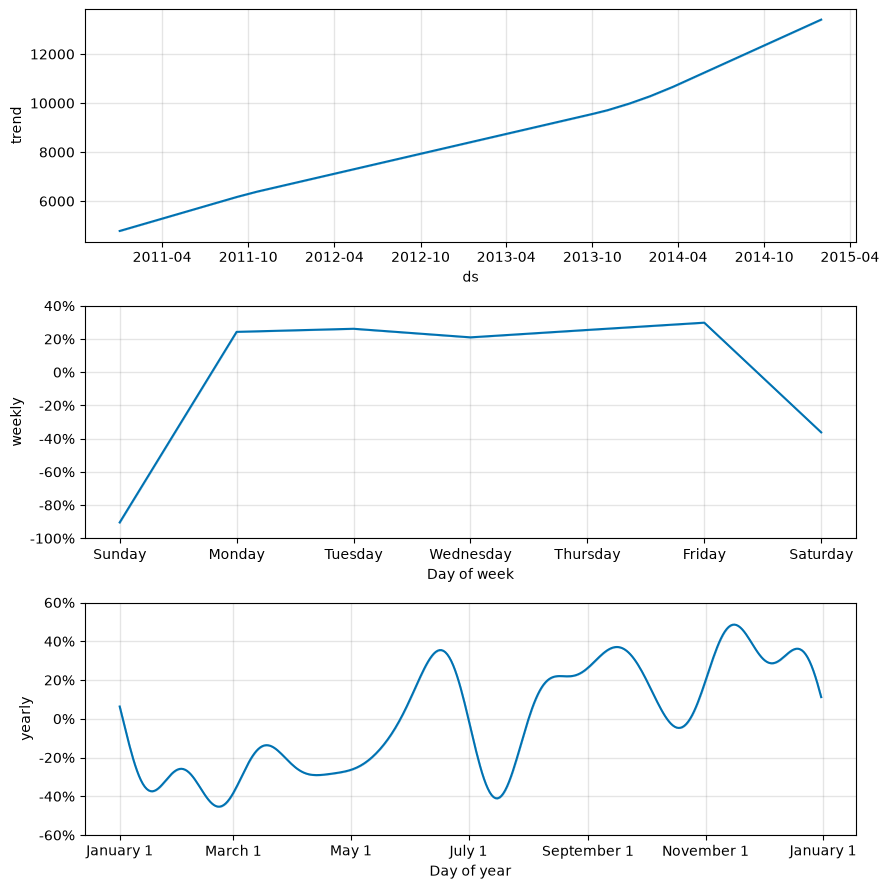

In [ ]:
model.plot_components(forecast);

In [ ]:
forecast.to_csv("sales_forecast.csv",index=False)

# DAY 5
Baseline Model Evaluation

In [ ]:
forecast_eval=model.predict(df[['ds']])

In [ ]:
results = df[['ds', 'y']].copy()

results['Predicted Sales'] = forecast_eval['yhat']
results.head(10)

,ds,y,Predicted Sales
0,2011-01-01,808.56300,3448.126393
1,2011-01-02,314.22000,664.526183
2,2011-01-03,4503.53720,5972.994599
3,2011-01-04,2808.87024,5875.008489
4,2011-01-05,3662.31000,5440.849031
5,2011-01-06,622.53810,5472.954738
6,2011-01-07,7123.01850,5508.294587
7,2011-01-08,6293.26000,2158.303305
8,2011-01-09,813.74940,-619.888948
9,2011-01-10,6794.18116,4777.088213


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    results['y'],
    results['Predicted Sales']
)

print(f"MAE: {mae:.2f}")

MAE: 3132.43


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    results['y'],
    results['Predicted Sales']
) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 166.76%


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        results['y'],
        results['Predicted Sales']
    )
)

print(f"RMSE: {rmse:.2f}")

RMSE: 4123.03


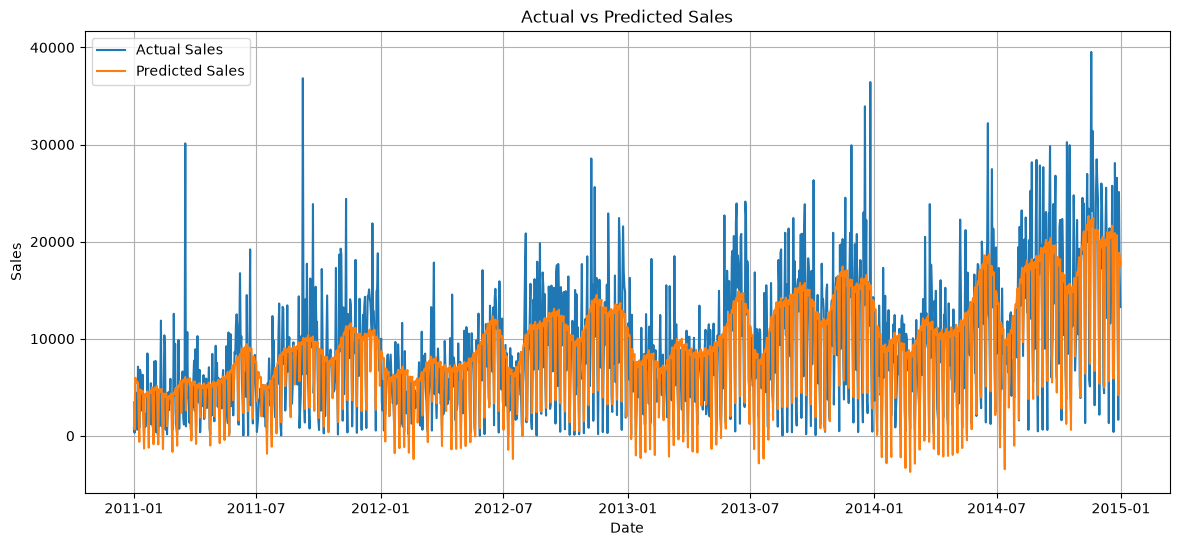

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    results['ds'],
    results['y'],
    label='Actual Sales'
)

plt.plot(
    results['ds'],
    results['Predicted Sales'],
    label='Predicted Sales'
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
results.to_csv(
    "model_evaluation.csv",
    index=False
)



In [ ]:
print("="*40)
print("MODEL EVALUATION SUMMARY")
print("="*40)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

MODEL EVALUATION SUMMARY
Mean Absolute Error (MAE): 3132.43
Root Mean Squared Error (RMSE): 4123.03
Mean Absolute Percentage Error (MAPE): 166.76%
